# Gaussian Process tool

This notebook is a walkthrough for the pipeline used by the GP reconstruction code

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
possible_derivatives = ['f','int','d1','d2']

# Settings

Here we specify the fixed settings of the reconstruction, namely the number and distribution of the $x$ points where the reconstruction is performed

In [3]:
N_recon = 5
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

# Create data to be reconstructed

Here we simulate data and errors for a completely made up observable

$$f(x) = \sum_{i=0}^N{a_ix^i}$$

where $N$ is the order of the polynomial and $a_i$ are the parameters controlling the $x$ trend of the observable

### Data settings

Settings controlling the data quality: number of measurements and their error

In [4]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

### Theory model

Here we specify the order of the polynomial observable and the fiducial values of its parameters

In [5]:
order = 1
fiducial = {'a0': 3,
            'a1': -1,
            #'a2': 5,
            #'a3': -0.1
           }

from reconstruction_tools.PolynomialFit import PolynomialFit
theory = PolynomialFit(None,None,order=order)
theory_model = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

### Data generation

In [6]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

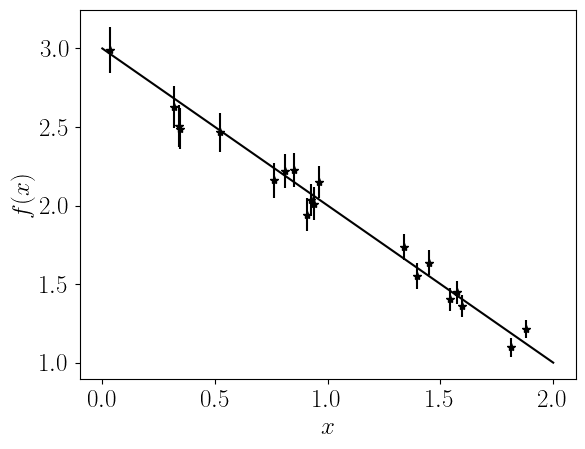

In [7]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
if theory_model != None:
    plt.plot(xplot,theory_model(xplot)['f'],color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Gaussian process

A Gaussian Process (GP) is the generalisation of a Gaussian distribution where, instead of looking at a random variable, we look at a distribution over functions.

Given a set of observational data $\mathbf{y}$ at positions $\mathbf{X}=\{x_i\}$, in the GP approach we assume that these are Gaussian representation of the underlying function $f(x)$

$$\mathbf{y}\sim\mathcal{N}(\mathbf{\mu},K(\mathbf{X},\mathbf{X})+C)\,,$$

where $\mathbf{\mu}$ is the mean of the distribution, $K(\mathbf{X},\mathbf{X})$ is the covariance matrix of the normal distribution and $C$ is the observational covariance which accounts for the measurement error.

This means that a new vector of values $\mathbf{f}^*$ for the underlying function at a set of points $\mathbf{X}^*$ can be written as 

$$\mathbf{f}^*\sim\mathcal{N}(\mathbf{\mu}^*,K(\mathbf{X}^*,\mathbf{X}^*))\,.$$

Jointly, the two GP for $\mathbf{y}$ and $\mathbf{f}^*$ can be written as

$$\begin{bmatrix} \mathbf{y} \\ \mathbf{f}^* \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} \mathbf{\mu} \\ \mathbf{\mu}^* \end{bmatrix}, \begin{bmatrix} K(\mathbf{X},\mathbf{X}) + C & K(\mathbf{X},\mathbf{X}^*) \\ K(\mathbf{X}^*,\mathbf{X}) & K(\mathbf{X}^*,\mathbf{X}^*) \end{bmatrix} \right)$$

The $\mathbf{y}$ points are known from observations, while we want to obtain the values of $\mathbf{f}^*$.

The mean and covariance of these values can be obtained as **REF**

$$\mathbf{f}^* = K(\mathbf{X},\mathbf{X}^*) (K(\mathbf{X},\mathbf{X}) + C)^{-1} \mathbf{y}\,,$$

$$\text{cov}(\mathbf{f}^*) = K(\mathbf{X}^*,\mathbf{X}^*) - K(\mathbf{X},\mathbf{X}^*) (K(\mathbf{X},\mathbf{X}) + C)^{-1} K(\mathbf{X}^*,\mathbf{X})$$


where we assumed $\mathbf{\mu}=\mathbf{\mu}^*=0$. (**explain why this is good**)


In the context of GP, the covariance $K$ is known as *Kernel* and can be chosen between different possibilities. Kernels contain some free parameters known as *hyper-parameters*.


Choosing the hyper-parameters (see below) and a Kernel, one can therefore obtain predictions for the target function at a set of $\mathbf{X}^*$ points, based on the observed $\mathbf{y}$.

Aside from the usefullness of reconstructing the target function, GP have another very useful property: the result of performing a linear operation on a GP returns a function that is still a GP **REF**.

This means that if we want to obtain the derivative of the target function (${\rm d}\,f/{\rm d}\,x$), once we reconstruct the function $f(x)$ with a GP, the derivative can be rewritten as

$$\mathbf{f}'^* = \frac{\partial K(\mathbf{X},\mathbf{X}^*)}{\partial \mathbf{X}_*} (K(\mathbf{X},\mathbf{X}) + C)^{-1} \mathbf{y}\,,$$

with the derivative covariance being

$$\text{cov}(f'(x), f'(x')) = \frac{\partial^2}{\partial x \partial x'} k(x, x')$$

and the covariance between the function and the derivative being

$$\text{cov}(f(x), f'(x')) = \frac{\partial}{\partial x'} k(x, x')$$

This holds not just for the first derivative but also for higher orders (as long as one can obtain derivatives of the kernel) and integrals. We refer to **REF** for a more extended discussion

## The GP class: GPCalculator

The main code allowing to use GP to reconstruct a given function is contained in `reconstruction_tools/GaussianProcess.py`, which contains the `GPCalculator` class.

blablabla

In [8]:
from reconstruction_tools.GaussianProcess import GPCalculator

## Available Kernels

**WRITE KERNELS HERE**

In [9]:
available_kernels = ['RBF','MATERN3/2','MATERN5/2']

## Simple run

The GPCalculator class can be initialized by giving as input the dataset and the covariance matrix 
for the function to reconstruct, together with the selected kernel.

After that, one can obtain a reconstruction straightforwardly by specifying the values of the kernel's hyperparameters (and nsteps **CHECK**)

The output of the reconstruction method is the mean values of the function at given points and the covariance of the predicted values.

This is not done only for the function itself, but also for its derivatives (up to the second when possible) and its integral.
For the latter, we need to specify the starting point of the integral and the number of steps taken.

**WARNING: SOMETHING WEIRD HAPPENING WITH THE SECOND DERIVATIVES IN MATERN KERNELS... REMOVING THEM FOR NOW!**

In [10]:
l     = 1
sigma = 1
integral_start = 0.
n_int_steps = 50

In [12]:
dfs = []
for kernel in available_kernels:
    tini = time()
    gp = GPCalculator(dataset,covmat,kernel_type=kernel)
    mu,cov = gp.predict_at_params(x_recon,l,sigma,0,integral_start,n_int_steps)
    
    #Unpacking results in human format (this is done in the code with the full approach)
    results = gp._unpack(mu,cov,x_recon)
    mean_df = pd.DataFrame({'x':x_recon}|results['means'])
    
    mean_df['Kernel'] = kernel 
        
    cols = []
    for func in results['means'].keys():
        cols = cols+['{}_{}'.format(func,ind) for ind in range(len(x_recon))]
    covmat_df = pd.DataFrame(cov,columns=cols,index=cols)
    
    for func in possible_derivatives:
        cov = covmat_df[[func+'_{}'.format(ind) for ind in range(N_recon)]]
        cov = cov.drop(index=[ind for ind in cov.index if ind not in [func+'_{}'.format(ind) for ind in range(N_recon)]])
        mean_df[func+'_err'] = np.sqrt(np.diag(cov))

    #TEMPORARY! (I hope)
    if kernel != 'RBF':
        mean_df['d2']     = np.nan
        mean_df['d2_err'] = np.nan 

    print(kernel+' done in {:.2f} s'.format(time()-tini))

    dfs.append(mean_df)

simple_GP = pd.concat(dfs,ignore_index=True)

TypeError: 'int' object is not subscriptable

In [ ]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for kernel in simple_GP['Kernel'].unique():
        df = simple_GP[simple_GP['Kernel']==kernel]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(simple_GP,x='x',y=deriv,hue='Kernel',ax=axes[i,j])
    else:
        sb.lineplot(simple_GP,x='x',y=deriv,hue='Kernel',ax=axes[i,j],legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Choosing hyper-parameters

The choice of hyper-parameters can be handled by the GPCalculator class, which offers the possibility
to switch between an optimization approach and a marginalization approach.

For this example we fix the kernel to RBF

In [13]:
reconstructions = {}

In [14]:
gp = GPCalculator(dataset,covmat,kernel_type='RBF')

### Optimized

**Explain optimization here**

In [15]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='MAP')

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Optimized'] = {'Functions': means,
                                'Covmat': joint_cov}

best_fit = info['Best-fit']

GP done in 11.73 s


### Marginalized

**Explain marginalization here**

In [16]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Marginalized'] = {'Functions': means,
                                   'Covmat': joint_cov}

sample = info['sample']

Removed no burn in
GP done in 145.37 s


### Visualize hyper-parameters

In [17]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot(sample,['l','sigma'],legend_loc='upper right',
                filled=False,contour_lws=2,
                markers=best_fit
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

Exception: parameter name not found: l

### Comparison

In [18]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

In [19]:
results

,x,f,d1,d2,int,f_err,d1_err,d2_err,int_err,Method
0,0.0,2.763386,-0.589868,-0.434141,0.000000,0.259669,0.359183,0.298403,0.000000,Optimized
1,0.5,2.418134,-0.782392,-0.329409,1.299396,0.153841,0.252411,0.321121,0.099203,Optimized
2,1.0,1.991195,-0.913976,-0.193041,2.404464,0.110500,0.187038,0.332059,0.153559,Optimized
3,1.5,1.516284,-0.973129,-0.042903,3.282548,0.115470,0.229151,0.326252,0.181255,Optimized
4,2.0,1.030526,-0.957840,0.101536,3.918908,0.199106,0.332881,0.306076,0.200507,Optimized
5,0.0,2.755794,-0.576470,-0.485018,0.000000,0.307277,0.585812,0.869163,0.000000,Marginalized
6,0.5,2.411342,-0.789518,-0.345055,1.296244,0.164586,0.317089,0.702860,0.109348,Marginalized
7,1.0,1.981993,-0.910599,-0.139784,2.397090,0.117499,0.224497,0.496539,0.163028,Marginalized
8,1.5,1.516683,-0.937085,0.022825,3.272282,0.120289,0.273032,0.589778,0.188044,Marginalized
9,2.0,1.055835,-0.897643,0.127216,3.914566,0.223086,0.459658,0.683314,0.204574,Marginalized


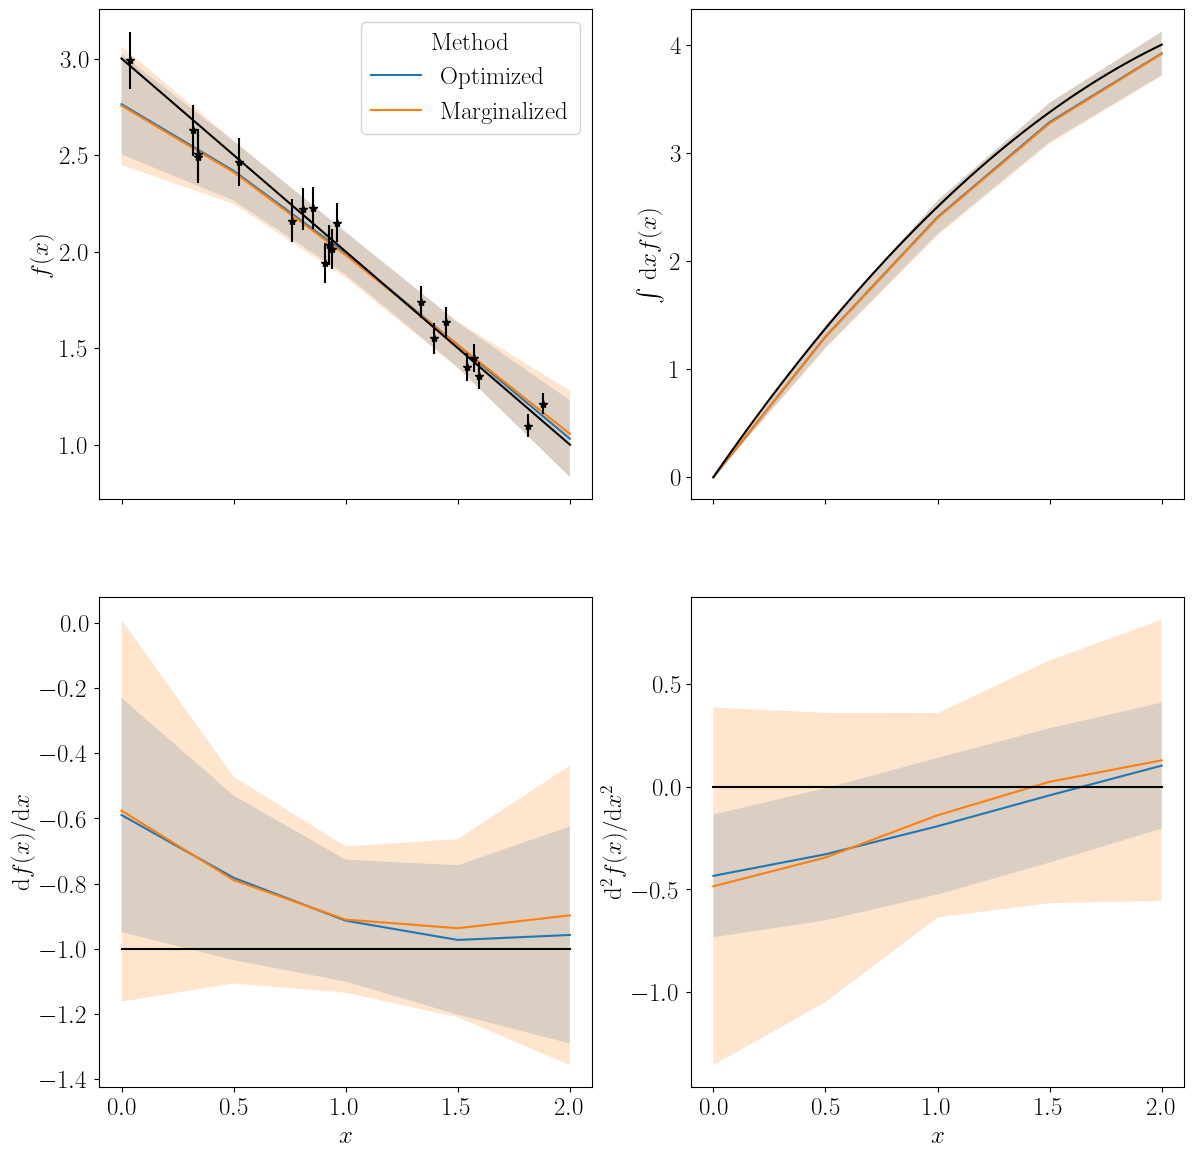

In [20]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Method'].unique():
        df = results[results['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j],legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

# GP diagnostics

**EXPLAIN DIAGNOSTICS HERE**

In [ ]:
from utils.diagnostics import Scorer

In [ ]:
score = {}

In [ ]:
for k,v in reconstructions.items():
    score[k] = Scorer(v['Functions'],v['Covmat'],chatty=True)

## Theory score

Here we test against a fiducial function...

In [ ]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory_model(x_recon)[func] for func in ['f','d1','d2','int']})

###  Malahanobis distance

Explain full $\chi^2$ and what we see here

In [ ]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_theory(theory_df)

### Diagonal distance

Explain diagonal $\chi^2$ and what we see here

In [ ]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_pointwise(theory_df)

## Comparison with data

In [ ]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [ ]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_data(datasets)

# Gaussian Process reconstruction for correlated data

The GP module of CoRe is also able to handle reconstruction when the data from which reconstruct separate functions are correlated.

**EXPLAIN METHOD HERE**

Here we create the data for two functions $f_1(x)$ and $f_2(x)$ assuming including a correlation between the measurements of each function when they are performed at the same $x$. We assume the correlation factor to be uniformly distributed between 0 and 1 

In [21]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

In [22]:
order = 1
fiducial = {'a0': 3,
            'a1': -1,
            #'a2': 5,
            #'a3': -0.1
           }

from reconstruction_tools.PolynomialFit import PolynomialFit
theory = PolynomialFit(None,None,order=order)
theory_func_1 = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

In [23]:
order = 2
fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            #'a3': -0.1
           }

from reconstruction_tools.PolynomialFit import PolynomialFit
theory = PolynomialFit(None,None,order=order)
theory_func_2 = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

In [26]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_func_1(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f1'] = np.random.normal(thvals,errors)
dataset['f1_err'] = errors

thvals = theory_func_2(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f2'] = np.random.normal(thvals,errors)
dataset['f2_err'] = errors

dataset['r(f1,f2)'] = np.random.uniform(0,1,len(dataset))
dataset

,x,f1,f1_err,f2,f2_err,"r(f1,f2)"
0,0.044371,2.914726,0.148274,2.914788,0.148274,0.191884
1,0.546355,3.621563,0.197308,3.944912,0.197308,0.194993
2,1.938662,19.376009,0.992669,21.379136,0.992669,0.385923
3,1.278500,10.258548,0.494715,9.478008,0.494715,0.110962
4,0.938438,5.849799,0.323244,6.494314,0.323244,0.757996
5,0.328429,3.406316,0.160545,3.350514,0.160545,0.547304
6,0.011964,2.942428,0.149438,2.806698,0.149438,0.069009
7,1.583763,13.446332,0.697888,14.595765,0.697888,0.542566
8,1.157375,8.669839,0.427011,8.436926,0.427011,0.696988
9,1.394893,10.318072,0.566687,11.472825,0.566687,0.940900


In [27]:
covmat_1 = pd.DataFrame(np.diag(errors*2),columns=['f1_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat_1.index = covmat_1.columns

covmat_2 = pd.DataFrame(np.diag(errors*2),columns=['f2_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat_2.index = covmat_2.columns

cov_cross = np.diag([row['f1_err']*row['f2_err']*row['r(f1,f2)'] for ind,row in dataset.iterrows()])

joint_matrix = np.block([[covmat_1.values,  cov_cross],
                         [cov_cross.T, covmat_2.values]])

N = len(dataset)
labels = [f"f1_{i}" for i in range(N)] + [f"f2_{i}" for i in range(N)]
covmat = pd.DataFrame(joint_matrix, columns=labels, index=labels)

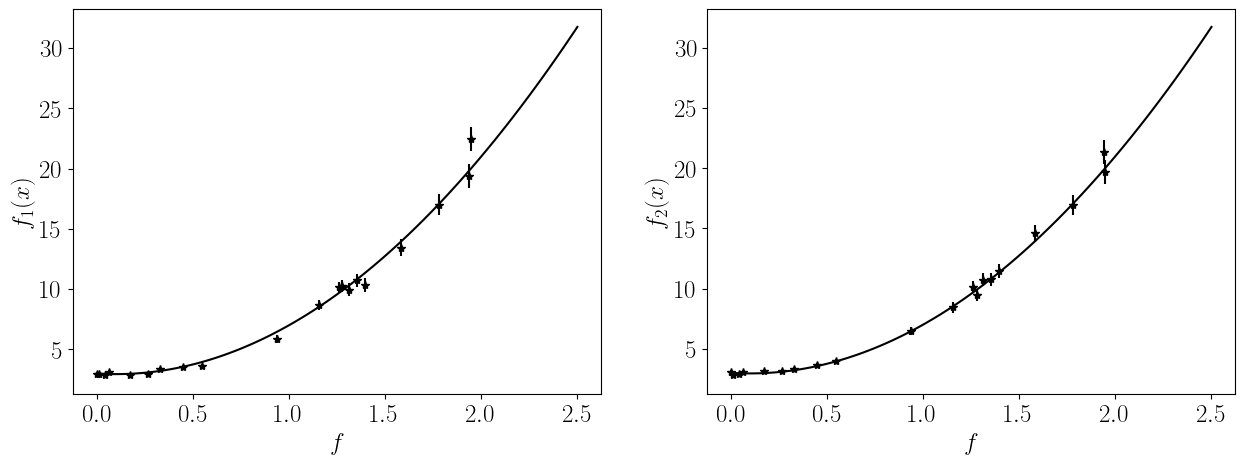

In [29]:
xplot = np.linspace(0.01,2.5,100)

fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(15,5))

axes[0].plot(xplot,theory_func_1(xplot)['f'],color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$f$')
axes[0].set_ylabel(r'$f_1(x)$')

axes[1].plot(xplot,theory_func_2(xplot)['f'],color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$f$')
axes[1].set_ylabel(r'$f_2(x)$');

## Uncorrelated reconstruction

## Correlated reconstruction

## Plotting